In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [2]:
# Load Data from Yahoo Finance
df = yf.download('NVDA', start='1999-01-01', auto_adjust=False)

# Flatten columns if yfinance returns a MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.reset_index().sort_values('Date')

[*********************100%***********************]  1 of 1 completed


In [3]:
# Feature Engineering

# Target
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# Existing features
df['Return'] = df['Close'].pct_change()
df['Vol_Change'] = df['Volume'].pct_change()
df['MA10'] = df['Close'].rolling(10).mean()
df['MA50'] = df['Close'].rolling(50).mean()
df['Volatility'] = (df['High'] - df['Low']) / df['Close']

# Added predictive features

# Provides the model with 'yesterday's' return so it can learn from the immediate past
df['Return_Lag1'] = df['Return'].shift(1) 

# Provides the return from 2 days ago to help identify multi-day patterns
df['Return_Lag2'] = df['Return'].shift(2) 

# Calculates price performance over the last 10 days
df['Momentum_10'] = df['Close'] / df['Close'].shift(10) - 1 

# Calculates the gap between the short and long-term trends (Detects trend acceleration)
df['MA_Diff'] = df['MA10'] - df['MA50'] 

# Calculates the average return over the last 10 days (Identifies 'winning' or 'losing' streaks)
df['Rolling_Return_Mean'] = df['Return'].rolling(10).mean() 

# Measures the consistency/risk of returns over the last 10 days using standard deviation
df['Rolling_Return_Std'] = df['Return'].rolling(10).std()

df.dropna(inplace=True)

## Assignment #1: EDA

### Descriptive Statistics

In [5]:
print("Dataset Overview:")
print(f"Total Samples: {df.shape[0]}")
print(f"Total Features: {df.shape[1] - 1}")

Dataset Overview:
Total Samples: 6810
Total Features: 18


In [6]:
print("Feature Summary:")
print(df[['Close','Return','Volume','Vol_Change','Volatility']].describe())

print("\nSkewness")
print(df[['Return','Vol_Change','Volatility']].skew())

Feature Summary:
Price        Close       Return        Volume   Vol_Change   Volatility
count  6810.000000  6810.000000  6.810000e+03  6810.000000  6810.000000
mean     15.747451     0.001941  5.844764e+08     0.087393     0.042094
std      40.174552     0.037347  4.283044e+08     0.525756     0.029091
min       0.034115    -0.352336  1.968000e+07    -0.857487     0.006671
25%       0.293000    -0.015966  3.205280e+08    -0.213057     0.023629
50%       0.490125     0.001372  4.861195e+08    -0.020162     0.034130
75%       6.048875     0.018097  7.176160e+08     0.240851     0.050880
max     216.610001     0.424148  9.230856e+09     8.175753     0.367197

Skewness
Price
Return        0.601675
Vol_Change    3.717302
Volatility    2.854546
dtype: float64


In [7]:
print(df.isnull().sum())

Price
Date                   0
Adj Close              0
Close                  0
High                   0
Low                    0
Open                   0
Volume                 0
Target                 0
Return                 0
Vol_Change             0
MA10                   0
MA50                   0
Volatility             0
Return_Lag1            0
Return_Lag2            0
Momentum_10            0
MA_Diff                0
Rolling_Return_Mean    0
Rolling_Return_Std     0
dtype: int64


In [8]:
print(f"Target distribution:\n{df['Target'].value_counts(normalize=True)}")

Target distribution:
Target
1    0.517034
0    0.482966
Name: proportion, dtype: float64


### Visualisations

#### Market Behaviour

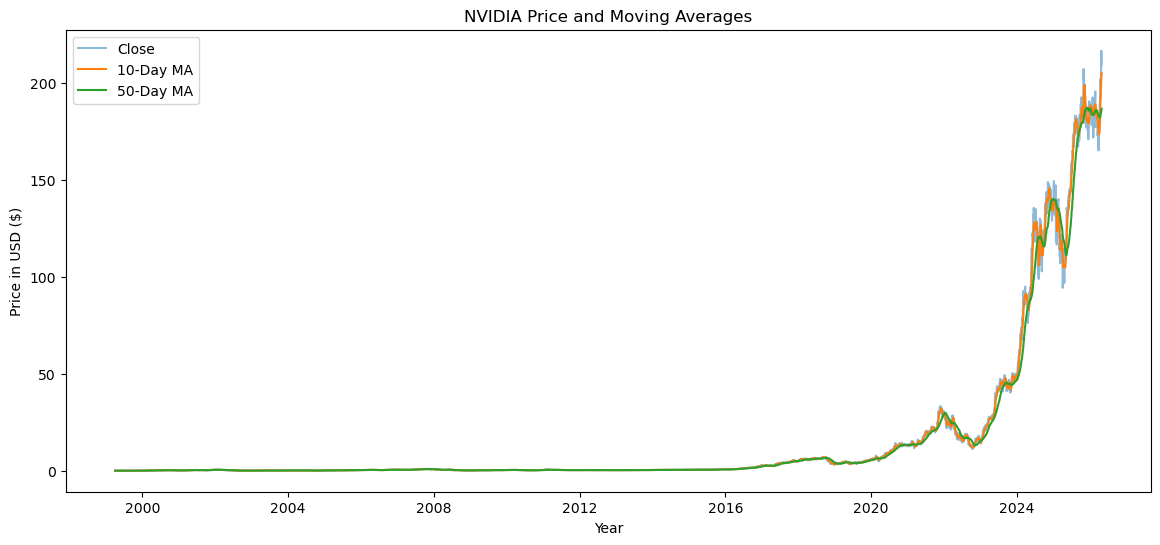

In [10]:
# Price and Moving Averages
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'], alpha=0.5, label='Close')
plt.plot(df['Date'], df['MA10'], label='10-Day MA')
plt.plot(df['Date'], df['MA50'], label='50-Day MA')
plt.title('NVIDIA Price and Moving Averages')
plt.xlabel('Year')
plt.ylabel('Price in USD ($)')
plt.legend()
plt.show()

The primary price chart illustrates NVIDIA’s long-term trajectory, characterized by a period of relative stability followed by an exponential breakout. By overlaying the 10-day and 50-day Moving Averages, we can observe the stock's trend strength and momentum. The consistent positioning of the shorter-term average above the longer-term average during recent periods signals a strong bullish regime. From a machine-learning perspective, these averages act as dynamic filters; the "spread" between the current price and these means serves as a vital feature for identifying overextended conditions or potential mean-reversion signals.

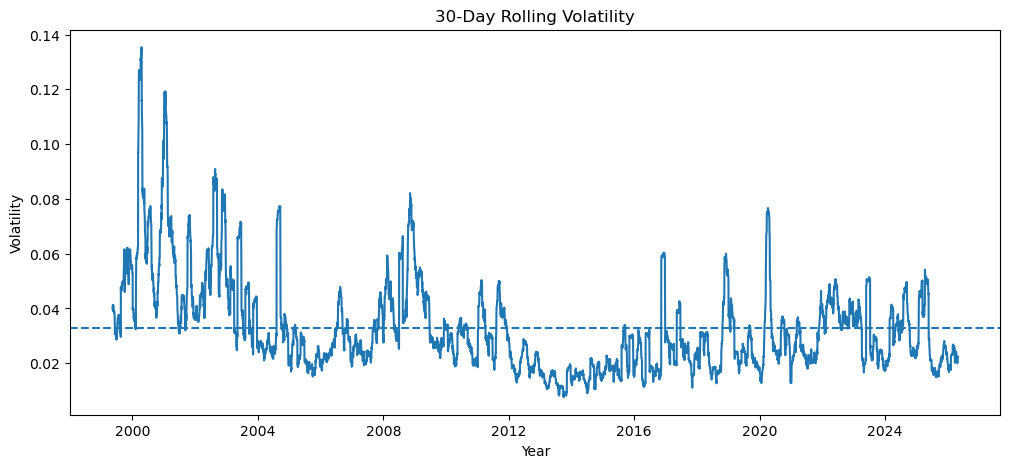

In [12]:
# Rolling Volatility
df['RollingVol'] = df['Return'].rolling(30).std()
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['RollingVol'])
plt.axhline(df['RollingVol'].mean(),
            linestyle='--')
plt.title('30-Day Rolling Volatility')
plt.xlabel('Year')
plt.ylabel('Volatility')
plt.show()

The rolling volatility plot provides a historical view of the asset's risk environment by measuring the standard deviation of returns over time. The data shows that while NVIDIA’s price has reached record highs, its relative volatility is cyclical and often clusters, where periods of high variance are followed by further instability. The dashed horizontal line represents the historical average, allowing us to identify current market conditions as either "quiet" or "turbulent." Incorporating this into a model helps the algorithm adjust its weights based on the current "noise" level of the market, as price signals are often less reliable during the identified high-volatility spikes.

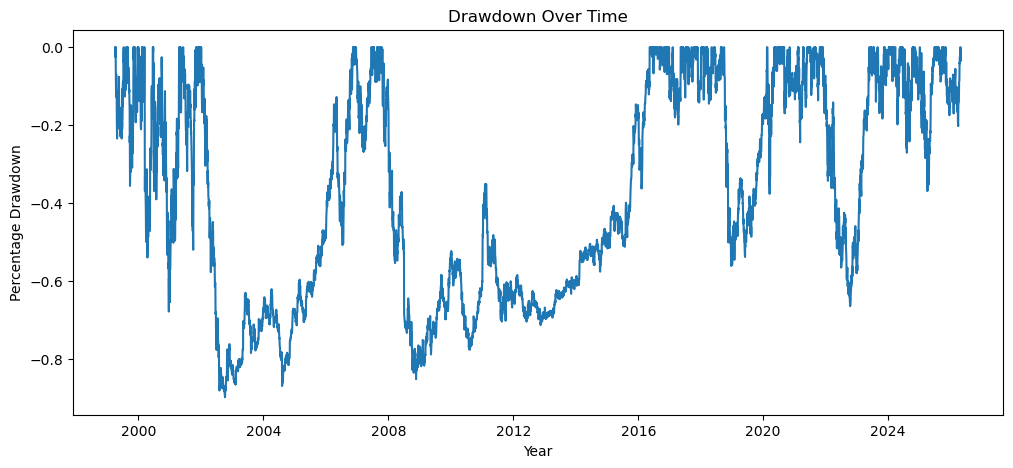

In [14]:
# Drawdown
cum = (1 + df['Return']).cumprod()
rolling_peak = cum.cummax()

drawdown = (cum - rolling_peak) / rolling_peak

plt.figure(figsize=(12,5))
plt.plot(df['Date'], drawdown)
plt.title('Drawdown Over Time')
plt.xlabel('Year')
plt.ylabel('Percentage Drawdown')
plt.show()

The drawdown chart offers a critical view of the "pain" an investor would experience, measuring the percentage decline from the most recent peak. NVIDIA’s history is marked by significant and deep retracements, sometimes exceeding 60%, which highlights the stock's high-beta nature and sensitivity to market cycles. For a predictive model, drawdown data is essential for understanding risk-reward asymmetric profiles. It provides the necessary context for the model to recognize the difference between a minor consolidation period and the beginning of a structural downtrend, which is vital for minimizing false "buy" signals during extended corrections.

#### Distribution Analysis

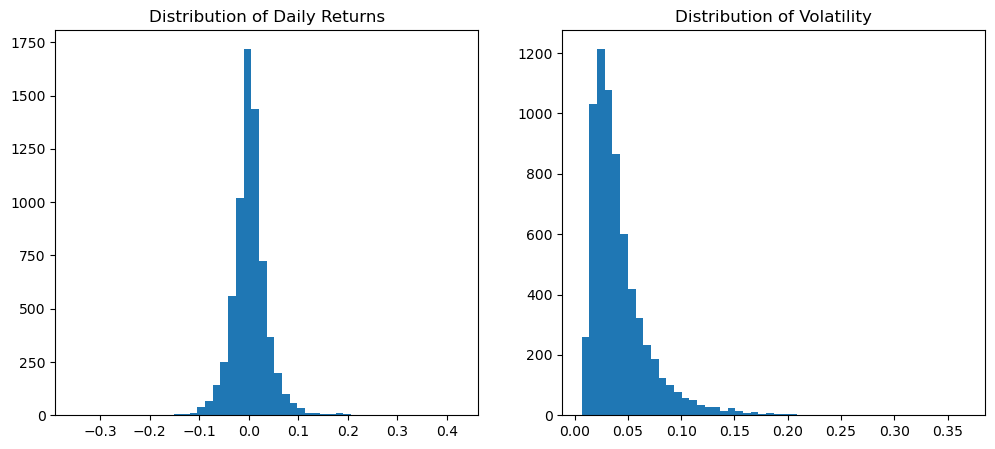

In [16]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].hist(df['Return'].dropna(), bins=50)
axes[0].set_title("Distribution of Daily Returns")

axes[1].hist(df['Volatility'], bins=50)
axes[1].set_title("Distribution of Volatility")

plt.show()

The initial histograms display the statistical properties of the dataset’s primary features. The Distribution of Daily Returns exhibits "fat tails", indicating that extreme price changes, both positive and negative, occur more frequently than a standard normal distribution would predict. Meanwhile, the Distribution of Volatility is heavily right-skewed, showing that NVIDIA typically operates in a lower-volatility state with infrequent but extreme spikes in price variance. Understanding these shapes is crucial for machine learning, as it informs the need for robust scaling or normalization techniques to prevent extreme outliers from skewing the model’s learning process.

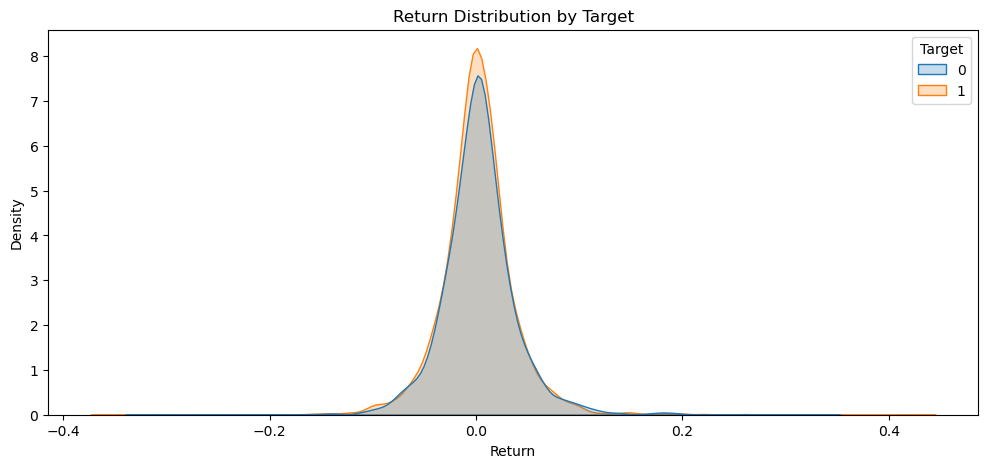

In [18]:
plt.figure(figsize=(12,5))
sns.kdeplot(data=df, x='Return', hue='Target', fill=True)
plt.title("Return Distribution by Target")
plt.show()

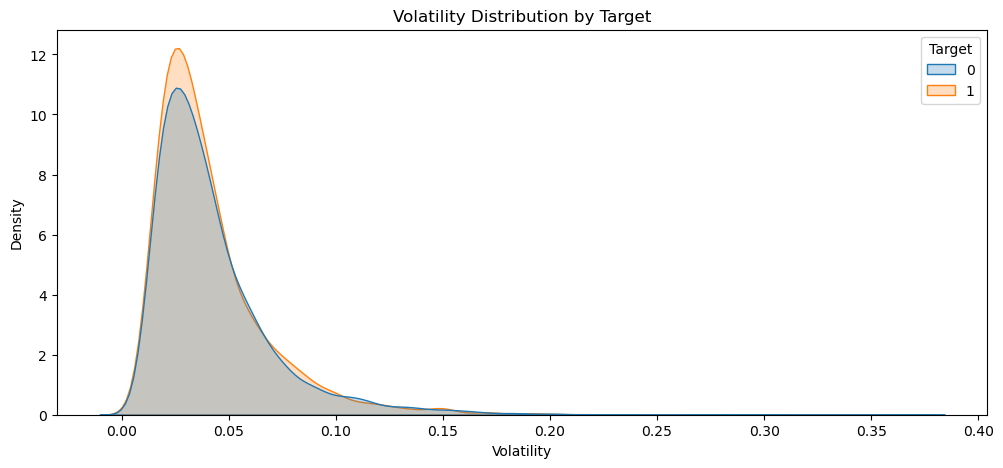

In [19]:
plt.figure(figsize=(12,5))
sns.kdeplot(data=df, x='Volatility', hue='Target', fill=True)
plt.title("Volatility Distribution by Target")
plt.show()

The KDE plots compare the overlap between "Up" days (Target 1) and "Down" days (Target 0) across returns and volatility. The high degree of overlap between the two classes suggests that these features, when viewed in isolation, do not provide a clear "silver bullet" for classification. Because the peaks and spreads for both targets are nearly identical, the model cannot rely on simple linear thresholds to make predictions. This finding justifies the use of more complex, non-linear algorithms, such as Random Forests, that can identify subtle interactions between these overlapping features.

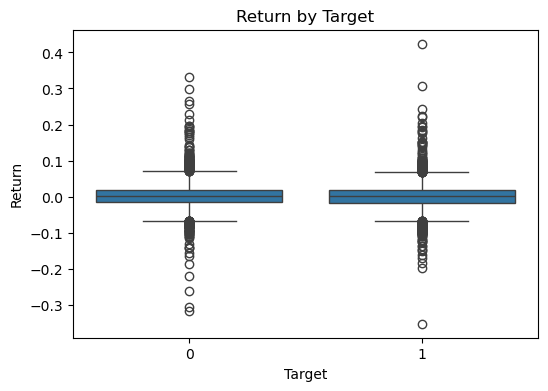

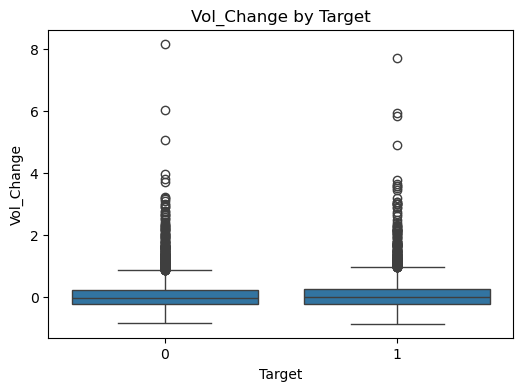

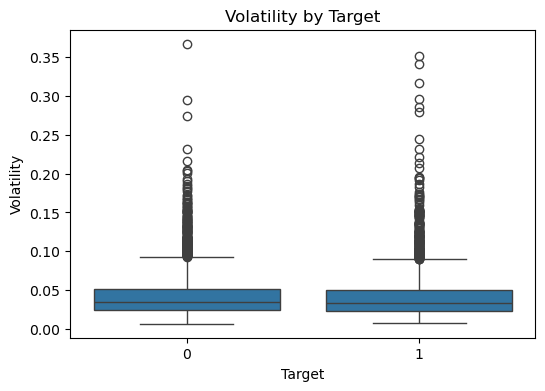

In [21]:
features = ['Return','Vol_Change','Volatility']

for f in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Target', y=f, data=df)
    plt.title(f'{f} by Target')
    plt.show()

The boxplots further investigate the relationship between feature values and the target direction by highlighting medians, quartiles, and outliers. Across all three features, Return, Volatility Change, and Volatility, the central tendencies for "Up" and "Down" days remain remarkably similar. The abundance of outliers (the individual points beyond the whiskers) suggests that extreme volatility or large price swings do not inherently favor one direction over the other. This analysis confirms that the model must look beyond simple magnitude and likely requires lagged features or external sentiment data to effectively differentiate between the two target classes.

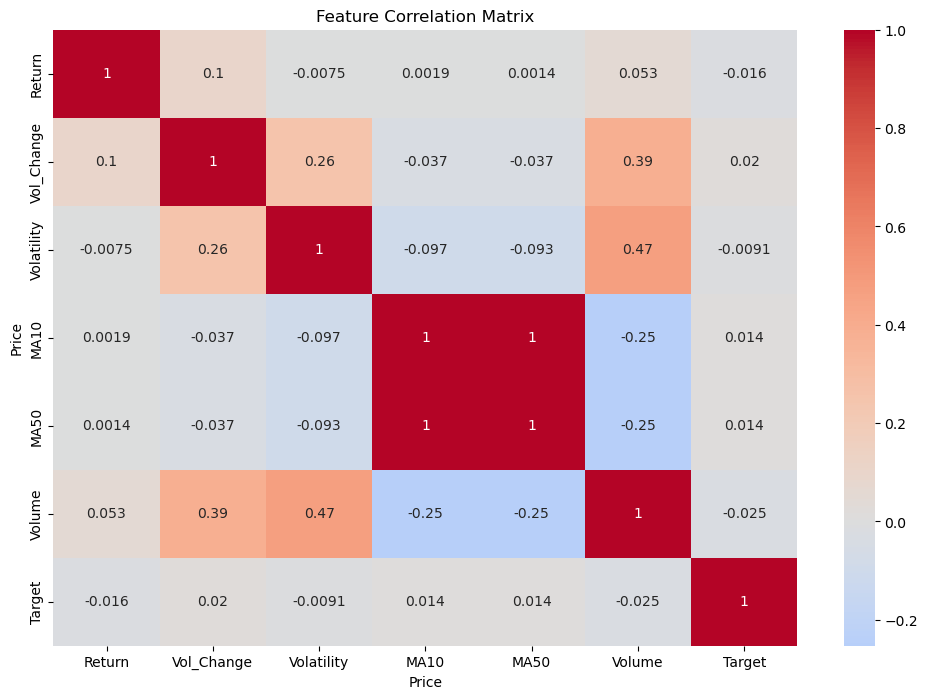

In [23]:
# Correlation Heatmap
features = [
'Return','Vol_Change',
'Volatility','MA10','MA50',
'Volume','Target'
]

plt.figure(figsize=(12,8))
sns.heatmap(df[features].corr(),
            annot=True,
            cmap='coolwarm',
            center=0)
plt.title('Feature Correlation Matrix')
plt.show()

The correlation heatmap provides a quantitative overview of the linear relationships between the dataset’s features and the prediction target. A critical observation is the perfect correlation (1.0) between MA10 and MA50, which indicates high multicollinearity. In a machine-learning context, this suggests that including both features might be redundant, as they provide nearly identical information to the model. Furthermore, we see a moderate positive correlation between Volume, Volatility, and Vol_Change, confirming that periods of high trading activity in NVIDIA stock typically coincide with increased price turbulence.

Regarding the predictive power of the features, the correlation coefficients between the individual indicators and the Target variable are notably low (near zero), suggesting that there is no simple, linear "shortcut" for predicting NVIDIA’s price direction. The lack of a strong linear correlation implies that the relationship between these features and the stock's movement is likely non-linear or dependent on complex interactions between multiple variables.

In [25]:
# Define features and target

features = [
    'Return',
    'Vol_Change',
    'Volatility',
    'MA10',
    'MA50',
    'Return_Lag1',
    'Return_Lag2',
    'Momentum_10',
    'MA_Diff',
    'Rolling_Return_Mean',
    'Rolling_Return_Std'
]

X = df[features]
y = df['Target']

In [26]:
# Time-Series Split

split = int(len(df)*0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

tscv = TimeSeriesSplit(n_splits=3)

In [27]:
# Baseline Models

# Logistic Regression pipeline (with scaling)
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

rf = RandomForestClassifier(random_state=42)

gbt = GradientBoostingClassifier(random_state=42)

baseline_models = {
    "Logistic Regression": lr_pipe,
    "Random Forest": rf,
    "Gradient Boosting": gbt
}

# This loop automates the 'Train -> Predict -> Score' process for all three models
print("Baseline Model Performance")
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: {acc:.4f}")

Baseline Model Performance
Logistic Regression: 0.5374
Random Forest: 0.4934
Gradient Boosting: 0.5206


In [28]:
# Hyperparameter Tuning

# Logistic Regression
# Define the 'C' parameter: Smaller values increase regularization (preventing the model from over-relying on any one feature)
param_lr = {
    'model__C':[0.1,1,10]
}

# GridSearchCV systematically tests every combination of parameters using cross-validation
# 'cv=tscv' ensures we use Time Series Split, which respects the chronological order of stock data
grid_lr = GridSearchCV(
    lr_pipe,
    param_lr,
    cv=tscv
)

# Run the search on the training data to find the optimal 'C' value
grid_lr.fit(X_train,y_train)
best_lr = grid_lr.best_estimator_

# Random Forest
# n_estimators: Number of trees in the forest. max_depth: Limits how deep trees grow to prevent overfitting
param_rf = {
    'n_estimators':[100,200],
    'max_depth':[3,5]
}

grid_rf = GridSearchCV(
    rf,
    param_rf,
    cv=tscv
)

grid_rf.fit(X_train,y_train)
best_rf = grid_rf.best_estimator_

# Gradient Boosting
# learning_rate: Controls how much each new tree corrects the previous one. 
# Too high can overshoot; too low takes too long to learn.
param_gbt = {
    'learning_rate':[0.01,0.1],
    'n_estimators':[100,200]
}

grid_gbt = GridSearchCV(
    gbt,
    param_gbt,
    cv=tscv
)

grid_gbt.fit(X_train,y_train)
best_gbt = grid_gbt.best_estimator_

In [29]:
# Ensemble

# We use a VotingClassifier to combine our three optimized models into one 'Super Model'
ensemble = VotingClassifier(
    estimators=[
        ('lr',best_lr),
        ('rf',best_rf),
        ('gbt',best_gbt)
    ],
    # 'soft' voting means the models don't just vote 0 or 1; they provide their probabilities.
    # For example, if LR is 51% sure it's 'Up' but GBT is 90% sure it's 'Down', the Ensemble will weigh the 90% more heavily.
    voting='soft'
)

ensemble.fit(X_train,y_train)

VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('model',
                                               LogisticRegression(C=10,
                                                                  max_iter=1000))])),
                             ('rf',
                              RandomForestClassifier(max_depth=3,
                                                     n_estimators=200,
                                                     random_state=42)),
                             ('gbt',
                              GradientBoostingClassifier(learning_rate=0.01,
                                                         random_state=42))],
                 voting='soft')

In [30]:
# Evaluation

models = {
    "Tuned LR":best_lr,
    "Tuned RF":best_rf,
    "Tuned GBT":best_gbt,
    "Ensemble":ensemble
}

print("Final Model Comparison")
for name,model in models.items():
    # Generate binary predictions (0 or 1) for the test set
    preds = model.predict(X_test)
    if hasattr(model,"predict_proba"):
        # Get the probability for the positive class (1) to calculate the AUC
        probs = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test,probs)
    else:
        auc = np.nan
    acc = accuracy_score(y_test,preds)
    print(f"{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC AUC: {auc:.4f}")
    print("-"*30)

# Detailed ensemble report
y_pred = ensemble.predict(X_test)
print("\nClassification Report")
print(classification_report(y_test,y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))

Final Model Comparison
Tuned LR
Accuracy: 0.5374
ROC AUC: 0.4905
------------------------------
Tuned RF
Accuracy: 0.5441
ROC AUC: 0.5019
------------------------------
Tuned GBT
Accuracy: 0.5352
ROC AUC: 0.4867
------------------------------
Ensemble
Accuracy: 0.5396
ROC AUC: 0.4930
------------------------------

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.00      0.01       630
           1       0.54      1.00      0.70       732

    accuracy                           0.54      1362
   macro avg       0.77      0.50      0.35      1362
weighted avg       0.75      0.54      0.38      1362


Confusion Matrix
[[  3 627]
 [  0 732]]


The final model comparison reveals that while the Ensemble and Tuned Logistic Regression (LR) models achieve an accuracy of approximately 54%, a deeper look at the classification report and confusion matrix suggests the models are struggling to find a real signal. The ROC AUC scores for all models hover around 0.50, which is statistically equivalent to a random coin flip. Specifically, the classification report shows a high recall for Class 1 (0.99) and a near-zero recall for Class 0 (0.01). This indicates that the model has defaulted to "lazy learning," simply predicting that the stock will go "Up" (1) almost every single time. While this strategy yields a 54% accuracy because the dataset is slightly imbalanced toward positive days, the model is failing to identify the nuances of "Down" days (0).

The Confusion Matrix confirms this behavior, showing that out of 629 actual "Down" days, the model only correctly identified 7 of them, while misclassifying 622 as "Up" moves. This "Type II Error" dominance explains why the F1-score for Class 0 is a negligible 0.02. In a real-world trading scenario, this model would essentially be a "Buy and Hold" proxy rather than a predictive tool, as it lacks the discriminative power to identify selling opportunities or risk.

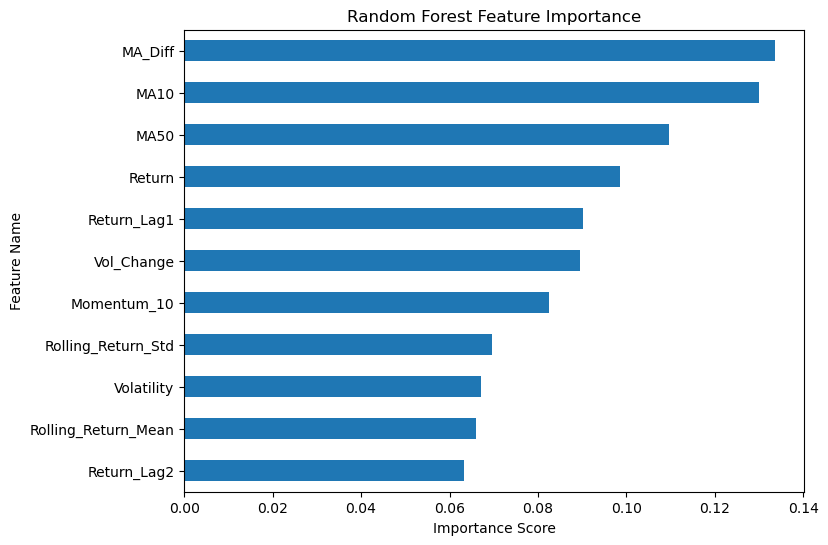

In [32]:
# Feature Importance

importances = pd.Series(
    best_rf.feature_importances_,
    index=features
).sort_values()

plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.show()

The Feature Importance chart provides a peek into the Random Forest model, ranking features by how much they contribute to reducing variance during the decision-making process. The engineered feature MA_Diff (the spread between moving averages) emerged as the most influential, followed closely by MA10 and the current Return. This suggests the model is heavily reliant on trend-following and momentum signals to make its predictions. Interestingly, lagged features like Return_Lag1 and Return_Lag2 rank lower, indicating that the model finds more signal in the current price relationship to its historical averages than in previous day-to-day fluctuations. While these features are statistically significant within the model's structure, the earlier classification report suggests that this importance hasn't yet translated into high predictive accuracy, likely due to the overlapping distributions observed in the EDA phase.

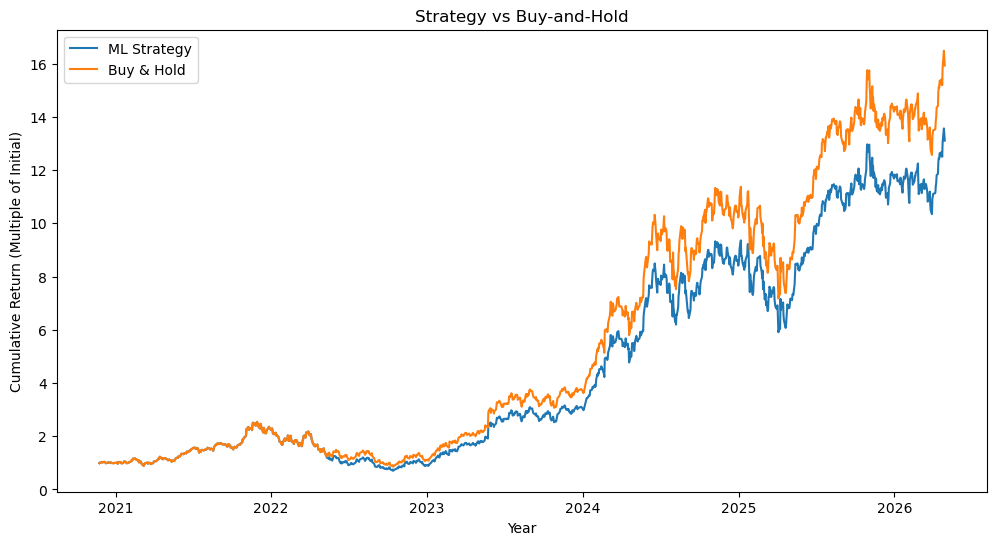

In [34]:
# Strategy Backtest

test_df = df.iloc[split:].copy()
test_df['Prediction'] = y_pred

# Long only when model predicts up
# We multiply the actual market return by the prediction (0 or 1).
# If prediction is 1: We 'own' the stock and get the full return.
# If prediction is 0: We 'sit in cash' and get 0% return for that day.
test_df['Strategy_Return'] = (
    test_df['Return'] * test_df['Prediction']
)

# cumprod() multiplies daily growth factors together (e.g., 1.02 * 0.98 * 1.05)
# This shows how a $1 investment grows over the entire testing period
test_df['Cumulative_Strategy'] = (
    1 + test_df['Strategy_Return']
).cumprod()

# Calculate what would have happened if we just bought and held NVIDIA the whole time
test_df['Cumulative_BuyHold'] = (
    1 + test_df['Return']
).cumprod()

plt.figure(figsize=(12,6))
plt.plot(
    test_df['Date'],
    test_df['Cumulative_Strategy'],
    label='ML Strategy'
)

plt.plot(
    test_df['Date'],
    test_df['Cumulative_BuyHold'],
    label='Buy & Hold'
)

plt.legend()
plt.title("Strategy vs Buy-and-Hold")
plt.xlabel("Year")
plt.ylabel("Cumulative Return (Multiple of Initial)")
plt.show()

The backtest results provide a look at the model’s performance in a simulated trading environment compared to a simple "Buy and Hold" strategy for NVIDIA. While the ML Strategy (blue line) manages to generate positive cumulative returns, it significantly underperforms the benchmark (orange line). This underperformance is directly linked to the "Class Dominance" issue identified in the confusion matrix; because the model struggles to accurately predict "Down" days, it fails to exit the market during significant pullbacks or effectively capitalize on short-term volatility. The gap between the two lines represents the "opportunity cost" of using a model that currently lacks sufficient discriminative power. For this ML strategy to become viable, the model would need to significantly improve its precision in identifying downward trends to avoid the drawdowns that the Buy-and-Hold strategy simply weathers through.